## Objective

This notebook covers the following tasks:
- Data preprocessing - feature selection and normalization
- Define the optimal number of clusters (Elbow Method + Silhouette Score)
- Train the K-Means model and assign clusters
- Interpret and name the identified profiles

## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

SEED = 42
np.random.seed(SEED)

DATA_DIR = "../data"
SYNTHETIC_PATH = os.path.join(DATA_DIR, "synthetic_dataset.csv")
REAL_DATA_PATH = os.path.join(DATA_DIR, "real_data.csv")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10,5)

print("Setup complete.")

Setup complete.


## 2. Load Dataset

In [2]:
USE_REAL_DATA = os.path.exists(REAL_DATA_PATH)

if USE_REAL_DATA:
    df = pd.read_csv(REAL_DATA_PATH)
    print(f"Real dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")
else:
    df = pd.read_csv(SYNTHETIC_PATH)
    print(f"Synthetic dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")

df.head()

Synthetic dataset loaded: 120 students, 10 columns


,student_name,linguistic_score,logical_math_score,spatial_score,bodily_kinesthetic_score,interpersonal_score,intrapersonal_score,emotional_regulation,engagement_frequency,generated_archetype
0,Brenda Alves,7.9,6.7,6.7,5.8,8.7,7.2,7.0,8.3,communicative
1,Sra. Isabelly Câmara,5.9,6.7,6.7,6.4,6.9,7.3,8.5,7.1,balanced
2,Cauã Rocha,7.2,6.9,5.5,7.0,7.0,9.0,6.8,7.2,balanced
3,Dra. Aurora Pastor,5.5,4.6,7.9,9.1,7.6,6.3,6.6,7.4,kinesthetic
4,Ana Beatriz Alves,7.5,10.0,7.7,5.0,5.6,6.6,5.8,7.1,analytical


## 3. Preprocessing

### 3.1 Feature Selection

Two columns are excluded from the model:
- `student_name` - identifier, not a feature
- `generated_archetype` - generation artifact, must not be used as model input

The original scores are kept in `df` for cluster interpretation later.

In [3]:
score_columns = [
    "linguistic_score",
    "logical_math_score",
    "spatial_score",
    "bodily_kinesthetic_score",
    "interpersonal_score",
    "intrapersonal_score",
    "emotional_regulation",
    "engagement_frequency"
]

X = df[score_columns].copy()

print(f"Features selected: {len(score_columns)}")
print(f"Dataset shape for modeling: {X.shape}")

Features selected: 8
Dataset shape for modeling: (120, 8)


### 3.2 Missing Value Treatment

Missing values in score columns are filled with the column mean.
This ensures the dataset remains complete without removing student records.

> **Note:** This treatment was already applied during the exploratory analysis
> in `01_exploratory_analysis.ipynb`. It is intentionally repeated here because
> both notebooks are independent - if this notebook is executed directly with
> real data, without running the EDA first, the treatment must still be guaranteed
> before the model receives the data.

In [4]:
X = X.fillna(X.mean())

print("Missing values after treatment:")
print(X.isnull().sum())

Missing values after treatment:
linguistic_score            0
logical_math_score          0
spatial_score               0
bodily_kinesthetic_score    0
interpersonal_score         0
intrapersonal_score         0
emotional_regulation        0
engagement_frequency        0
dtype: int64


### 3.3 Normalization - StandardScaler

K-Means is sensitive to the scale of variables - it uses Euclidean distance to assign points to clusters.  
Even though all variables are already on a 0-10 scale, StandardScaler is applied to ensure equal weight across dimensions and improve cluster separation.

StandardScaler transforms each variable to have **mean = 0** and **standard deviation = 1**.

> The original scores in `df` are preserved for cluster interpretation - only `X_scaled` is used for modeling.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled = pd.DataFrame(X_scaled, columns=score_columns)

print("Scaled dataset - summary statistics:")
X_scaled.describe().round(2)

Scaled dataset - summary statistics:


,linguistic_score,logical_math_score,spatial_score,bodily_kinesthetic_score,interpersonal_score,intrapersonal_score,emotional_regulation,engagement_frequency
count,120.00,120.00,120.00,120.00,120.00,120.00,120.00,120.00
mean,-0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.66,-2.43,-2.48,-2.38,-2.89,-2.61,-2.75,-1.75
25%,-0.72,-0.68,-0.69,-0.66,-0.77,-0.78,-0.66,-0.84
50%,0.04,-0.00,-0.09,0.00,0.08,0.01,0.12,-0.10
75%,0.62,0.70,0.69,0.53,0.68,0.66,0.70,0.74
max,2.48,2.19,2.48,2.38,2.54,3.79,2.27,2.18


## 4. Defining the Number of Clusters

### 4.1 Elbow Method

The Elbow Method evaluates the **inertia** (sum of squared distances from each point to its cluster centroid) for different values of k.  
The optimal k is where the inertia starts to decrease more slowly - the "elbow" of the curve.

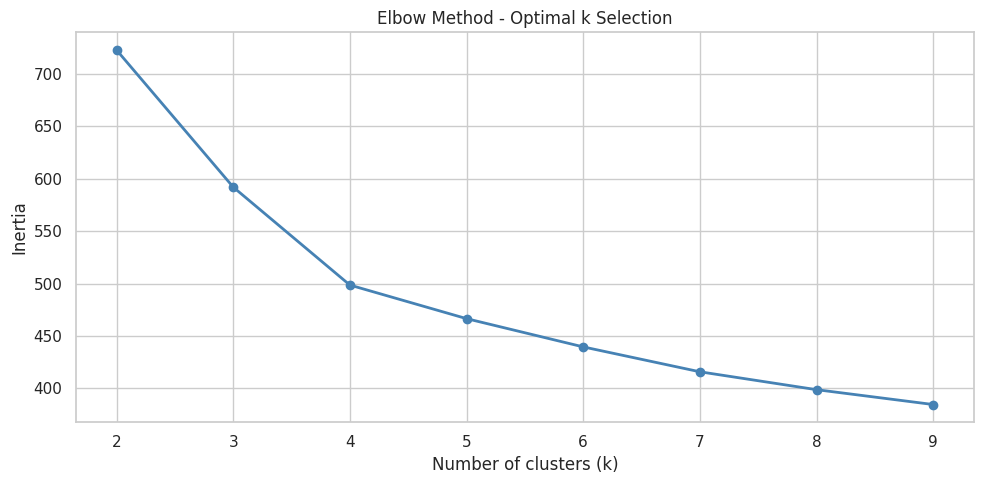

Plot saved to data/elbow_method.png


In [6]:
inertias = []
k_range = range(2,10)

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
  kmeans.fit(X_scaled)
  inertias.append(kmeans.inertia_)
  
plt.figure(figsize=(10,5))
plt.plot(k_range, inertias, marker='o', linewidth=2, color='steelblue')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method - Optimal k Selection")
plt.xticks(k_range)
plt.tight_layout()
plt.savefig("../data/elbow_method.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to data/elbow_method.png")

### 4.2 Silhouette Score

The Silhouette Score measures how similar a point is to its own cluster compared to other clusters.  
Values range from -1 to 1 - higher is better. A score above 0.40 indicates reasonable cluster separation.

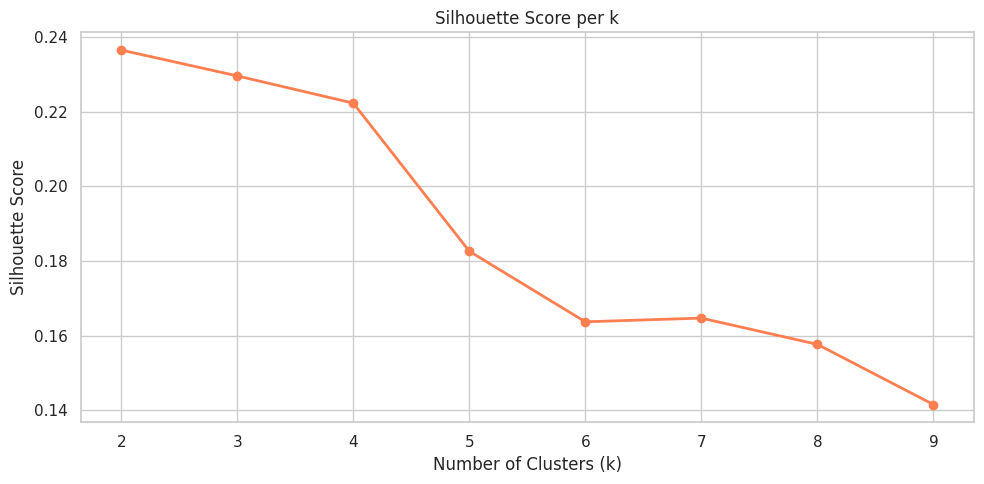

Plot saved to data/silhouette_scores.png


In [7]:
silhouette_scores = []

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
  labels = kmeans.fit_predict(X_scaled)
  score = silhouette_score(X_scaled, labels)
  silhouette_scores.append(score)
  
plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores, marker='o', linewidth=2, color='coral')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score per k")
plt.xticks(k_range)
plt.tight_layout()
plt.savefig("../data/silhouette_scores.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to data/silhouette_scores.png")

### 4.3 k Selection

The Elbow Method shows a clear inflection point at **k=4** for the synthetic data, where the
rate of inertia reduction decreases significantly. Although the
Silhouette Scores remain below 0.40 across all values of k - which is
expected given the overlapping nature of synthetic profiles generated
with Gaussian noise - k=4 presents the best balance between cluster
separation (highest Silhouette Score: ~0.24) and interpretability,
aligning with the four archetypes defined in the theoretical framework.

> The low Silhouette Scores reflect the intentional similarity between
> profiles in the synthetic dataset, not a failure of the model. With real data,
> scores may vary.

> **For real data users:** Do not assume k=4. Analyze the plots above
> and update `OPTIMAL_K` based on the elbow inflection point and the
> highest Silhouette Score for your specific dataset.

In [8]:
# Define k based on elbow and silhouette analysis
# Update this value after reviewing the plots above
OPTIMAL_K = 4

best_silhouette = silhouette_scores[list(k_range).index(OPTIMAL_K)]
print(f"Selected k: {OPTIMAL_K}")
print(f"Silhouette Score for k={OPTIMAL_K}: {best_silhouette:.4f}")

Selected k: 4
Silhouette Score for k=4: 0.2223


## 5. K-Means Model Training

In [9]:
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=SEED, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

print(f"K-Means trained with k={OPTIMAL_K}")
print(f"\nCluster distribution:")
print(df["cluster"].value_counts().sort_index())

K-Means trained with k=4

Cluster distribution:
cluster
0    23
1    20
2    43
3    34
Name: count, dtype: int64


## 6. Cluster Interpretation

### 6.1 Mean scores per cluster

The original (non-scaled) scores are used here for interpretation - they preserve the 0–10 scale and are more meaningful pedagogically.

In [10]:
cluster_means = df.groupby("cluster")[score_columns].mean().round(2)
print("Mean scores per cluster (original scale):")
cluster_means

Mean scores per cluster (original scale):


,linguistic_score,logical_math_score,spatial_score,bodily_kinesthetic_score,interpersonal_score,intrapersonal_score,emotional_regulation,engagement_frequency
cluster,,,,,,,,
0,8.62,6.91,6.80,6.57,8.38,7.12,6.92,8.85
1,5.59,5.44,7.28,8.56,7.14,6.99,5.56,8.54
2,7.03,6.81,6.94,7.21,6.98,6.99,7.02,7.04
3,6.90,8.58,8.45,5.58,5.66,7.28,7.27,6.95


### 6.2 Heatmap - cluster profiles

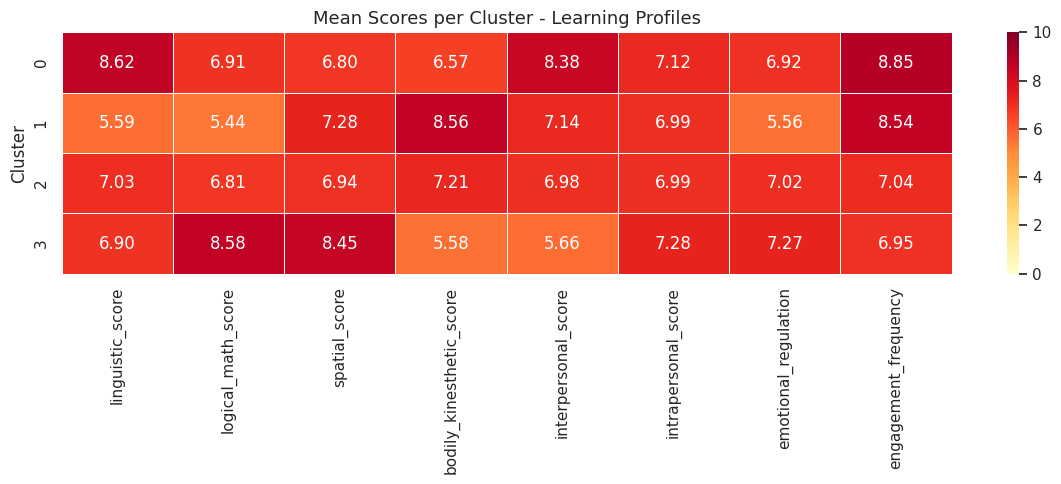

Plot saved to data/cluster_profiles.png


In [11]:
plt.figure(figsize=(12,5))
sns.heatmap(
  cluster_means,
  annot=True, fmt=".2f",
  cmap="YlOrRd",
  vmin=0, vmax=10,
  linewidths=0.5
)

plt.title("Mean Scores per Cluster - Learning Profiles", fontsize=13)
plt.ylabel("Cluster")
plt.tight_layout()
plt.savefig("../data/cluster_profiles.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to data/cluster_profiles.png")


### 6.3 Profile Naming

Based on the mean scores above, assign a descriptive name to each cluster.  
Update the dictionary below after reviewing the heatmap:

> The names should reflect the **dominant intelligence dimensions** of each cluster,
> consistent with Gardner's (1983) theoretical framework.

In [12]:
# Update cluster names based on heatmap analysis
cluster_names = {
    0: "Communicative", # High linguistic and interpersonal; moderate other dimensions
    1: "Kinesthetic", # High bodily-kinesthetic and engagement; lower linguistic and logical-math
    2: "Balanced", # Moderate scores across all dimensions; moderate socioemotional indicator
    3: "Analytical" # High logical-math and spatial; lower bodily-kinesthetic and interpersonal
}

df["profile"] = df["cluster"].map(cluster_names)

print("Profile distribution:")
print(df["profile"].value_counts())

Profile distribution:
profile
Balanced         43
Analytical       34
Communicative    23
Kinesthetic      20
Name: count, dtype: int64


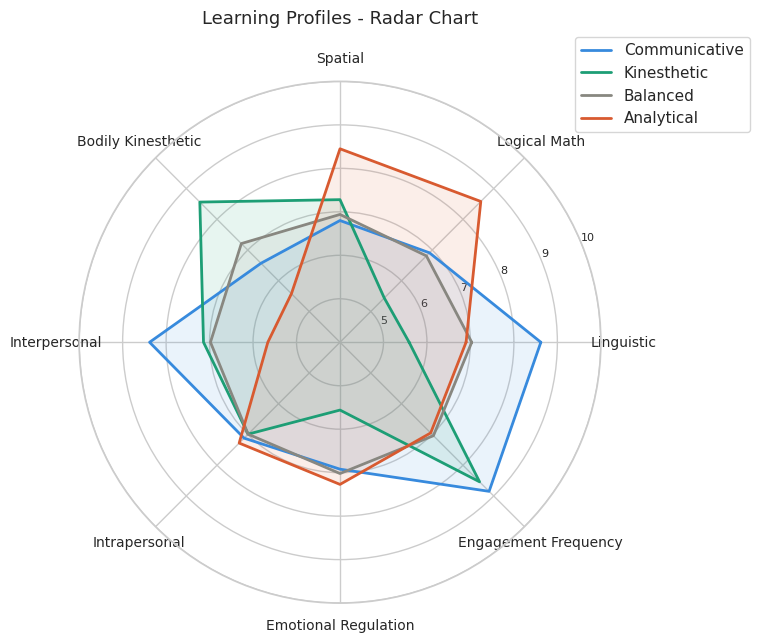

In [13]:
# Plotting radar chart

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

labels = [c.replace("_score", "").replace("_", " ").title() for c in score_columns]
N = len(labels)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

colors = ['#378ADD', '#1D9E75', '#888780', '#D85A30']

for i, (cluster_id, row) in enumerate(cluster_means.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, color=colors[i], label=cluster_names[cluster_id])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=10)
ax.set_ylim(4, 10)
ax.set_yticks([5, 6, 7, 8, 9, 10])
ax.set_yticklabels(['5','6','7','8','9','10'], size=8)
ax.set_title("Learning Profiles - Radar Chart", size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig("../data/cluster_radar.png", dpi=150, bbox_inches='tight')
plt.show()

### 6.4 PCA Scatter Plot

To visualize the cluster separation in 2D, Principal Component Analysis (PCA)
was applied to reduce the 8-dimensional feature space to 2 components.

> PCA is used here **only for visualization** - the K-Means model was trained
> on the full 8-dimensional scaled dataset. The scatter plot shows how well
> the clusters separate in a reduced space, but the actual cluster boundaries
> exist in 8 dimensions.

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

df["pca_1"] = X_pca[:, 0]
df["pca_2"] = X_pca[:, 1]

explained = pca.explained_variance_ratio_
print(f"Variance explained: PC1={explained[0]:.1%}, PC2={explained[1]:.1%}, Total={sum(explained):.1%}")

loadings = pd.DataFrame(
    pca.components_.T,
    index=score_columns,
    columns=["PC1", "PC2"]
).round(3)

print("\nPCA Loadings:")
print(loadings.sort_values("PC1", ascending=False))

Variance explained: PC1=33.5%, PC2=19.5%, Total=53.0%

PCA Loadings:
                            PC1    PC2
logical_math_score        0.497  0.064
emotional_regulation      0.333  0.366
spatial_score             0.321 -0.287
intrapersonal_score       0.122  0.284
linguistic_score          0.048  0.669
engagement_frequency     -0.371  0.232
interpersonal_score      -0.424  0.367
bodily_kinesthetic_score -0.452 -0.251


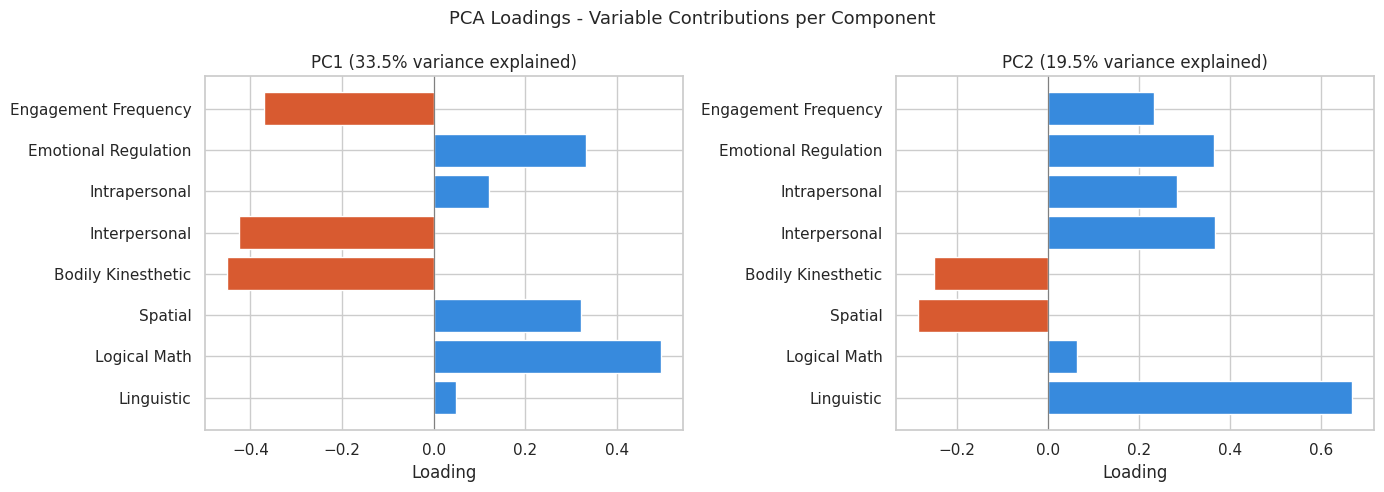

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, pc in enumerate(["PC1", "PC2"]):
    labels = [c.replace("_score", "").replace("_", " ").title() for c in score_columns]
    values = loadings[pc].values
    colors_bar = ['#378ADD' if v > 0 else '#D85A30' for v in values]

    axes[i].barh(labels, values, color=colors_bar)
    axes[i].axvline(x=0, color='gray', linewidth=0.8)
    axes[i].set_title(f"{pc} ({explained[i]:.1%} variance explained)")
    axes[i].set_xlabel("Loading")

plt.suptitle("PCA Loadings - Variable Contributions per Component", fontsize=13)
plt.tight_layout()
plt.savefig("../data/pca_loadings.png", dpi=150, bbox_inches='tight')
plt.show()

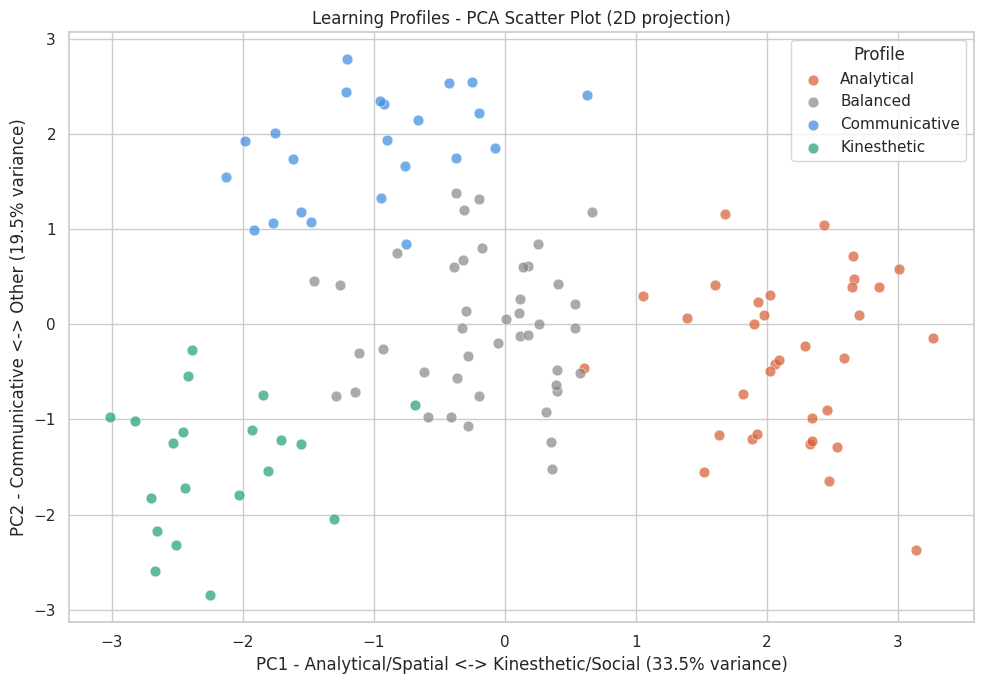

In [16]:
colors_scatter = {
    'Communicative': '#378ADD',
    'Kinesthetic':   '#1D9E75',
    'Balanced':      '#888780',
    'Analytical':    '#D85A30'
}

fig, ax = plt.subplots(figsize=(10, 7))

for profile, group in df.groupby("profile"):
    ax.scatter(
        group["pca_1"], group["pca_2"],
        label=profile,
        color=colors_scatter[profile],
        alpha=0.7, s=60, edgecolors='white', linewidths=0.5
    )

ax.set_xlabel(f"PC1 - Analytical/Spatial <-> Kinesthetic/Social ({explained[0]:.1%} variance)")
ax.set_ylabel(f"PC2 - Communicative <-> Other ({explained[1]:.1%} variance)")
ax.set_title("Learning Profiles - PCA Scatter Plot (2D projection)")
ax.legend(title="Profile")
plt.tight_layout()
plt.savefig("../data/cluster_scatter.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Final Dataset

In [18]:
output_path = os.path.join(DATA_DIR, "dataset_with_profiles.csv")
cols_to_save = [c for c in df.columns if c not in ["pca_1", "pca_2"]]
df[cols_to_save].to_csv(output_path, index=False)

print(f"***Final dataset saved to: {output_path}")
print(f"***Columns: {list(df.columns)}")
print(f"***Shape: {df.shape}")

***Final dataset saved to: ../data/dataset_with_profiles.csv
***Columns: ['student_name', 'linguistic_score', 'logical_math_score', 'spatial_score', 'bodily_kinesthetic_score', 'interpersonal_score', 'intrapersonal_score', 'emotional_regulation', 'engagement_frequency', 'generated_archetype', 'cluster', 'profile', 'pca_1', 'pca_2']
***Shape: (120, 14)
